In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


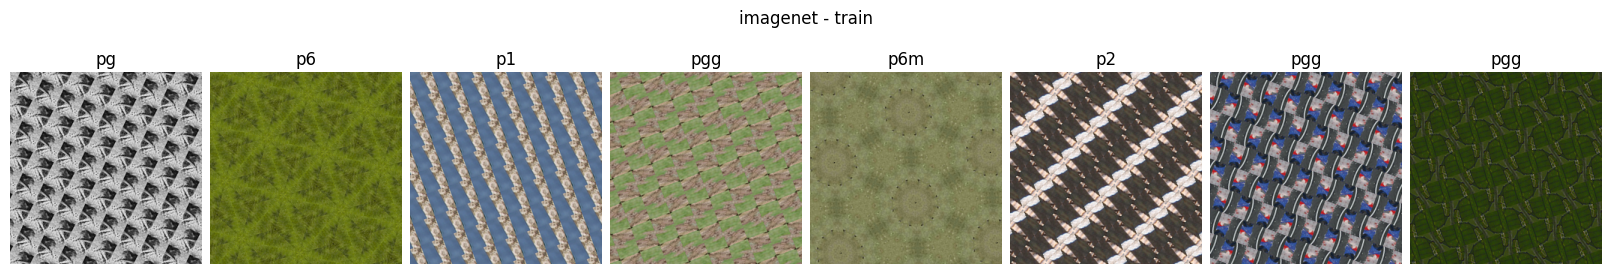

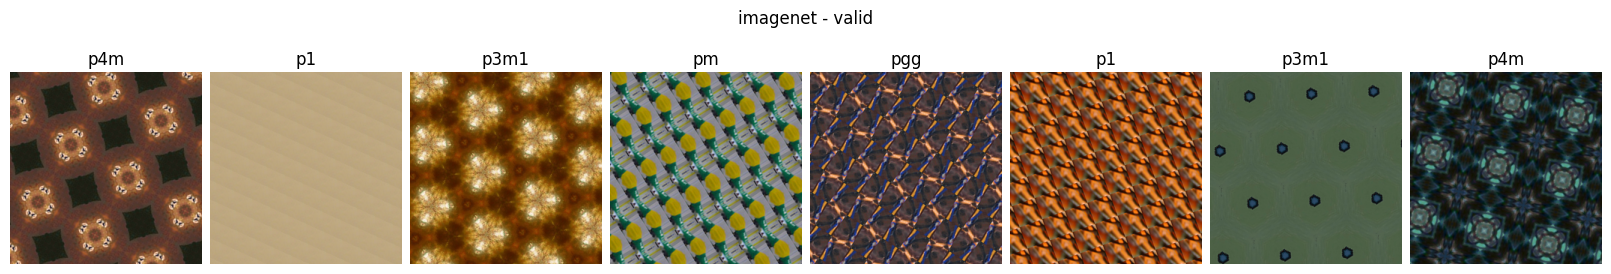

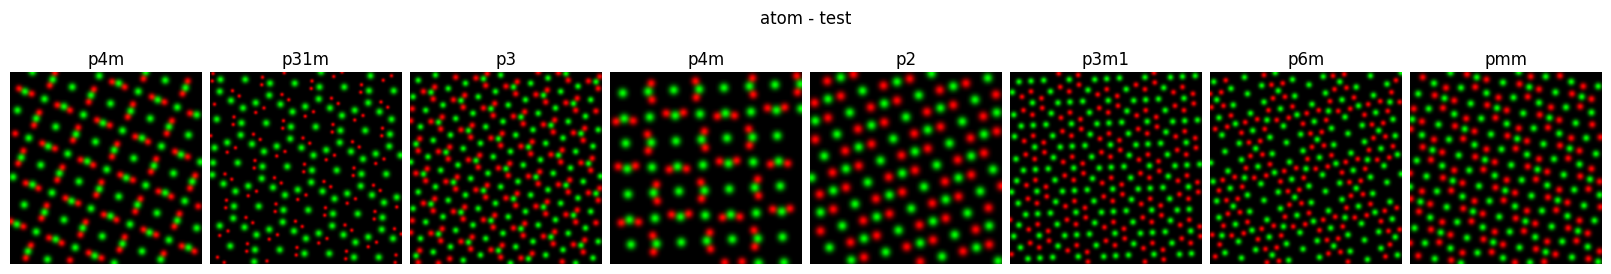

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet
valid_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
test_ds = hdf5_dataset('../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test')

In [10]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

torch.Size([2, 17])


In [6]:
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '01102024-benchmark-resnet50_from_scratch-v4_10m'

# train

In [8]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [9]:
device = config['device']
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 1/20


100%|██████████| 43479/43479 [5:22:41<00:00,  2.25it/s]  


Training: Loss: 0.4934, Accuracy: 83.5459%, Time: 322.6925mins


100%|██████████| 8696/8696 [25:57<00:00,  5.58it/s]


Validation : Loss : 0.0767, Accuracy: 97.5331%, Time: 25.97mins


...

100%|██████████| 8696/8696 [26:07<00:00,  5.55it/s]


Validation : Loss : 0.0037, Accuracy: 99.9144%, Time: 26.13mins


100%|██████████| 1985/1985 [27:08<00:00,  1.22it/s]


Validation : Loss : 5.8107, Accuracy: 57.9332%, Time: 27.15mins
Error in callback <function _WandbInit._pause_backend at 0x7fdbd998d550> (for post_run_cell):


FileNotFoundError: [Errno 2] No such file or directory: '/scratch/yichen/notebooks/1.Symmetry_Identification/symmetry_paper/1.benchmark/wandb/run-20230607_115744-05312023-benchmark-resnet50_from_scratch-v4_10m/tmp/code/05312023-benchmark-resnet50_from_scratch-dataset_v4-train.ipynb'